### PCA 

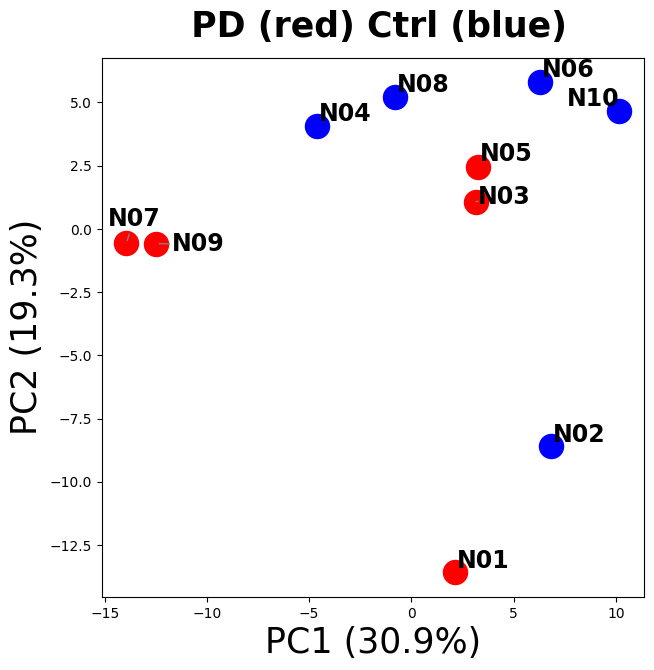

In [8]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from adjustText import adjust_text

# 1. Load data
df = pd.read_csv("data/PXD024748_LOG2_mean_intensity_matrix.csv")

# 2. Expression matrix
expr_cols = ["Ctrl N02","Ctrl N04","Ctrl N06","Ctrl N08","Ctrl N10",
             "PD N01","PD N03","PD N05","PD N07","PD N09"]

X = df[expr_cols].copy()
X.columns = X.columns.str.replace("PD ", "").str.replace("Ctrl ", "")

# Transpose (samples as rows)
X = X.T

# 3. PCA
pca = PCA(n_components=2)
pcs = pca.fit_transform(X)

# Variance explained
pc1_var = pca.explained_variance_ratio_[0] * 100
pc2_var = pca.explained_variance_ratio_[1] * 100

samples = X.index

# 4. Plot
plt.figure(figsize=(7,7))
texts = []

for i, s in enumerate(samples):
    color = "red" if any(tag in s for tag in ["N01", "N03", "N05", "N07", "N09"]) else "blue"
    plt.scatter(pcs[i,0], pcs[i,1], color=color, s=300)
    texts.append(
        plt.text(pcs[i,0], pcs[i,1], s, fontsize=17, weight="bold")
    )


# Adjust labels
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

# Labels
plt.xlabel(f"PC1 ({pc1_var:.1f}%)", fontsize=25)
plt.ylabel(f"PC2 ({pc2_var:.1f}%)", fontsize=25)

plt.title(" PD (red) Ctrl (blue)", fontsize=25, weight='bold', pad=15)

# Save (publication quality)
plt.savefig("figures/Proteomics_PCA_PD_vs_Control.png", dpi=300, bbox_inches="tight")

plt.show()

### VOLCANO PLOT

In [19]:
import pandas as pd

# Load Limma results
df_after_limma = pd.read_csv("PXD024748_limma_results_PD_vs_Ctrl.csv")

# Rename columns for consistency
df_after_limma = df_after_limma.rename(columns={"ID": "Gene names"})

# Select relevant columns
df_after_limma = df_after_limma[["Gene names", "log2FC", "P.Value"]]

# Filter significant proteins
sigs_proteins = df_after_limma[
    (df_after_limma["P.Value"] < 0.05) &
    (df_after_limma["log2FC"].abs() > 0.5)
]

print(f"Significant proteins: {sigs_proteins.shape[0]}")

# Sort by log2 fold change
sigs_proteins_sorted = sigs_proteins.sort_values(by="log2FC", ascending=False)
sigs_proteins_sorted

Significant proteins: 64


,Gene names,log2FC,P.Value
31,CTSL,1.641221,0.015879
62,GPD1,1.365584,0.029635
0,ANXA2,1.088640,0.000647
3,GLIPR2,1.055186,0.002476
57,CALB2,0.889207,0.027718
...,...,...,...
35,ERP44,-1.117115,0.017732
59,MIA3,-1.129699,0.028916
17,CDS2,-1.210896,0.009972
14,ALDH1A1,-1.278963,0.008717


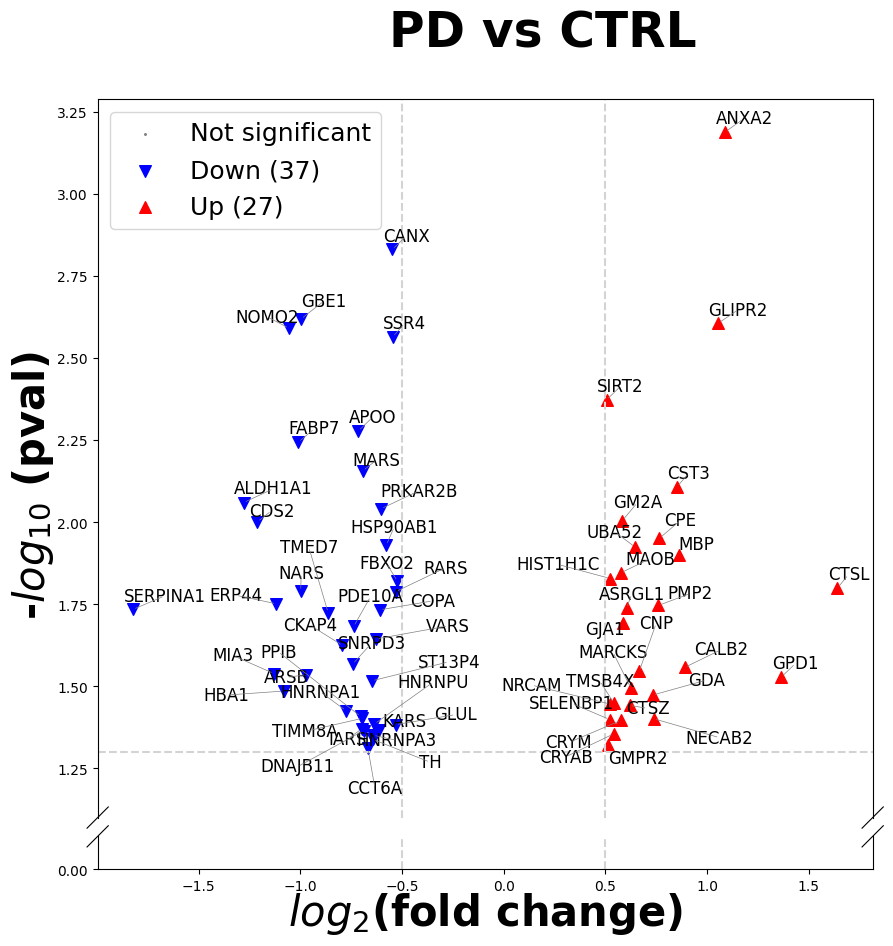

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from adjustText import adjust_text  
from brokenaxes import brokenaxes

# Copy data
df_lfq = sigs_proteins_sorted.copy()

# Avoid log(0) issues
df_lfq = df_lfq[df_lfq["P.Value"] > 0].copy()
df_lfq["neg_log10_p"] = -np.log10(df_lfq["P.Value"])

# Define thresholds
fc_thr = 0.5
p_thr = 0.05

down = df_lfq[(df_lfq["log2FC"] <= -fc_thr) & (df_lfq["P.Value"] <= p_thr)]
up   = df_lfq[(df_lfq["log2FC"] >= fc_thr) & (df_lfq["P.Value"] <= p_thr)]

down_count = len(down)
up_count = len(up)

# Y-axis range
y_max = -np.log10(df_lfq['P.Value'].min()) + 0.1

# Figure with broken y-axis
fig = plt.figure(figsize=(10, 10))

bax = brokenaxes(
    ylims=((0, 0.1), (1.1, y_max)),
    hspace=0.05,
    despine=False
)

# Background points
bax.scatter(
    df_lfq["log2FC"],
    df_lfq["neg_log10_p"],
    s=5,
    color="grey",
    marker=".",
    label="Not significant"
)

# Down-regulated
bax.scatter(
    x=down['log2FC'],
    y=-np.log10(down['P.Value']),
    s=70,
    color="blue",
    marker="v",
    label=f"Down ({down_count})"
)

# Up-regulated
bax.scatter(
    x=up['log2FC'],
    y=-np.log10(up['P.Value']),
    s=70,
    color="red",
    marker="^",
    label=f"Up ({up_count})"
)

# Gene labels
texts = []
for i, row in pd.concat([up, down]).iterrows():
    gene_name = str(row['Gene names']).split(";")[0]
    x = row['log2FC']
    y = -np.log10(row['P.Value'])
    
    # Görünür bölgede olanları etiketle
    if (0 <= y <= 0.1) or (y >= 1.1):
        texts.append(
            bax.text(
                x, y, gene_name,
                fontsize=12,
                ha='center',
                va='bottom',
                color='black'
            )
        )

# Etiket çakışmalarını düzelt
adjust_text(
    texts,
    arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
    expand_points=(1.2, 1.6),
    expand_text=(1.2, 1.6),
    force_points=0.3,
    force_text=0.4
)

# Reference lines
bax.axvline(-0.5, color="lightgrey", linestyle="--")
bax.axvline(0.5, color="lightgrey", linestyle="--")
bax.axhline(-np.log10(0.05), color="lightgrey", linestyle="--")

# Labels
bax.set_xlabel("$log_{2}$(fold change)", size=30, weight='bold')
bax.set_ylabel("-$log_{10}$ (pval)", size=30, weight='bold')
bax.legend(fontsize=18, loc='upper left')

fig.suptitle("PD vs CTRL", size=35, y=0.97, x=0.57, weight='bold')

#plt.savefig("Proteomics_LIMMA_VOLCANO_plot.png", dpi=300, bbox_inches='tight') 
plt.show()


### KEGG PATHWAY

In [44]:
import pandas as pd
import gseapy as gp

# Prepare gene list (DEPs)
gene_list = (
    sigs_proteins["Gene names"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

# Remove empty strings and duplicates
gene_list = gene_list[gene_list != ""].drop_duplicates().tolist()

print(f"Number of unique genes: {len(gene_list)}")


# Run Enrichr (KEGG)
enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=["KEGG_2021_Human"],
    organism="Human",   # NOTE: correct format
    outdir=None,
    cutoff=0.05
)

# Filter results
results = enr.results.copy()

filtered_results = results[
    (results["Adjusted P-value"] <= 0.05) &
    (results["Combined Score"] >= 30)
]


# Sort results
DEPs_pathways = filtered_results.sort_values(
    by="Combined Score",
    ascending=False
)

# Display settings for GitHub / notebook
pd.set_option("display.max_colwidth", None)

DEPs_pathways

Number of unique genes: 76


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
1,KEGG_2021_Human,Mitophagy,4/68,0.000130,0.005043,0,0,17.239583,154.206494,UBB;UBC;RPS27A;UBA52
0,KEGG_2021_Human,Protein processing in endoplasmic reticulum,7/171,0.000004,0.000307,0,0,12.223400,152.139037,HSP90AB1;SSR4;FBXO2;DNAJB11;CANX;CRYAB;CKAP4
2,KEGG_2021_Human,Ubiquitin mediated proteolysis,5/140,0.000194,0.005043,0,0,10.322900,88.239223,UBB;FBXO2;UBC;RPS27A;UBA52
3,KEGG_2021_Human,Spliceosome,5/150,0.000267,0.005210,0,0,9.606119,79.034556,HNRNPA3;HNRNPU;SNRPD3;HNRNPA1;HNRNPA1L2
6,KEGG_2021_Human,Antigen processing and presentation,3/78,0.003270,0.036434,0,0,10.876164,62.244978,HSP90AB1;CTSL;CANX
5,KEGG_2021_Human,Lysosome,4/128,0.001439,0.018702,0,0,8.870968,58.052075,GM2A;CTSL;CTSZ;ARSB
4,KEGG_2021_Human,Parkinson disease,6/249,0.000370,0.005774,0,0,6.942152,54.854354,TH;MAOB;UBB;UBC;RPS27A;UBA52


C:\Users\ayseg\AppData\Local\Programs\Python\Python311\Lib\site-packages\gseapy\plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


FDR < 0.05 


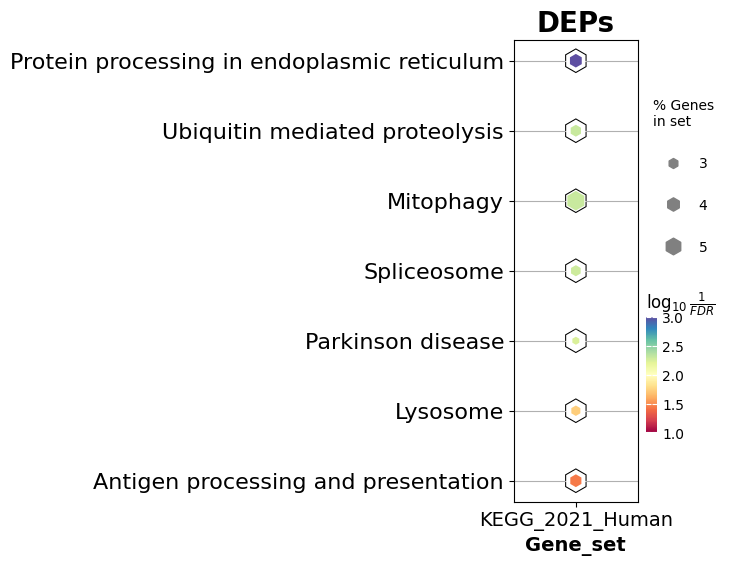

In [46]:
import gseapy as gp

# Optional: keep only needed columns
KEGG_result = DEPs_pathways[
    ["Gene_set", "Term", "Genes", "P-value",
     "Adjusted P-value", "Combined Score", "Overlap"]
].copy()

# Dotplot (KEGG enrichment)
ax = dotplot(DEPs_pathways,
              column="Adjusted P-value",
              x='Gene_set', # set x axis, so you could do a multi-sample/library comparsion
              size=40,
              top_term=10,
              figsize=(2,6),
              title = "DEPs",
              xticklabels_rot=0, # rotate xtick labels
              show_ring=True, # set to False to revmove outer ring
              cmap = 'Spectral',
              marker='h',
          pad=10,
             )


# Save the plot as a JPEG image with 300 dpi resolution
print ("FDR < 0.05 ")
ax.get_figure().savefig('Proteomics_GSEA_KEGG_enrichr_PDvsCtrl_DEPs_Limma.png', dpi=300, bbox_inches='tight')
plt.show()

### GO PATHWAY ANALYSIS

In [49]:
import gseapy as gp
import pandas as pd
import textwrap

# Prepare gene list
gene_list = (
    sigs_proteins["Gene names"]
    .dropna()
    .str.split(";")
    .explode()
    .str.strip()
)

# Remove empty strings + duplicates
gene_list = gene_list[gene_list != ""].drop_duplicates().tolist()

print(f"Number of genes: {len(gene_list)}")


# Run GO Enrichr
enr = gp.enrichr(
    gene_list=gene_list,
    gene_sets=[
        "GO_Biological_Process_2023",
        "GO_Molecular_Function_2023",
        "GO_Cellular_Component_2023"
    ],
    organism="Human",
    outdir=None,
    cutoff=0.05
)


# Filter results
results = enr.results.copy()

filtered_results = results[
    (results["Adjusted P-value"] <= 0.05) &
    (results["Combined Score"] >= 30)
].copy()


# Clean GO term names
filtered_results["Term"] = (
    filtered_results["Term"]
    .str.replace(r"\s*\(GO:\d+\)", "", regex=True)
)

filtered_results["Term"] = filtered_results["Term"].apply(
    lambda t: textwrap.fill(t, width=40)
)


# Final table
GO_result = filtered_results[
    ["Gene_set", "Term", "Genes",
     "P-value", "Adjusted P-value",
     "Combined Score", "Overlap"]
].sort_values(by="Combined Score", ascending=False)


pd.set_option("display.max_colwidth", None)

GO_result.head()

Number of genes: 76


,Gene_set,Term,Genes,P-value,Adjusted P-value,Combined Score,Overlap
0,GO_Biological_Process_2023,Modification-Dependent Macromolecule\nCatabolic Process,UBB;RPS27A;UBA52,0.000003,0.000944,2086.821954,3/8
1,GO_Biological_Process_2023,Multi-Pass Transmembrane Protein\nInsertion Into ER Membrane,NOMO3;NOMO1;NOMO2,0.000003,0.000944,2086.821954,3/8
784,GO_Cellular_Component_2023,COPI Vesicle Coat,COPA;TMED7,0.000918,0.012556,376.414542,2/12
4,GO_Biological_Process_2023,Protein Insertion Into ER Membrane,NOMO3;NOMO1;NOMO2,0.000179,0.023256,271.285000,3/29
787,GO_Cellular_Component_2023,COPI-coated Vesicle Membrane,COPA;TMED7,0.001652,0.018172,246.213298,2/16


C:\Users\ayseg\AppData\Local\Programs\Python\Python311\Lib\site-packages\gseapy\plot.py:753: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda _x: _x.sort_values(by=self.colname).tail(self.n_terms))


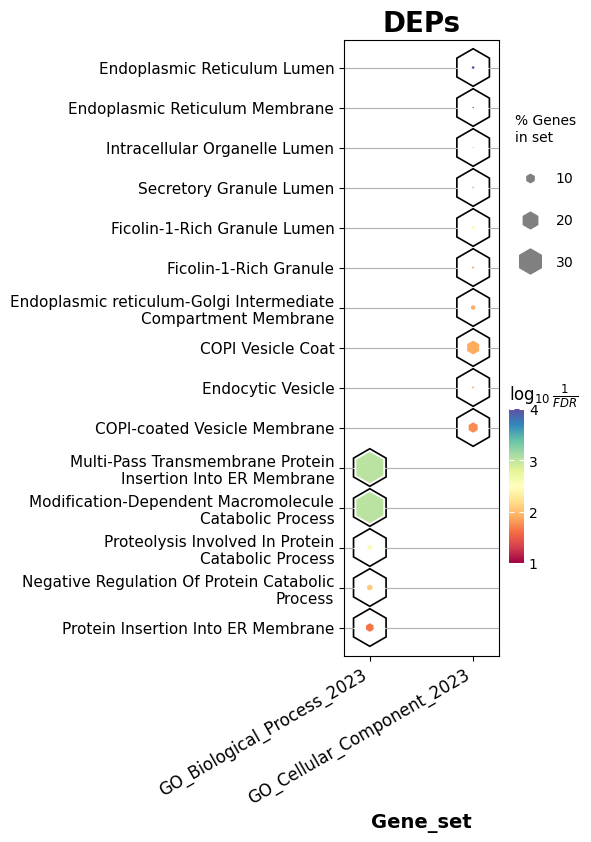

In [53]:
import matplotlib.pyplot as plt
from gseapy import dotplot

# Dotplot
ax = dotplot(
    filtered_results,
    column="Adjusted P-value",
    x='Gene_set',
    size=10,
    top_term=10,
    figsize=(2.5,8),
    title="DEPs",
    xticklabels_rot=30,
    show_ring=True,
    cmap='Spectral',
    marker='h',
    pad=20,
)

# Styling (clean + reproducible)
plt.setp(ax.get_yticklabels(), fontsize=11)
plt.setp(ax.get_xticklabels(), fontsize=12)

# Save figure
ax.get_figure().savefig('Proteomics_GSEA_GO_enrichr_PDvsCtrl_DEPs_Limma.png', dpi=300, bbox_inches='tight')
plt.show()



### VENN DIAGRAM

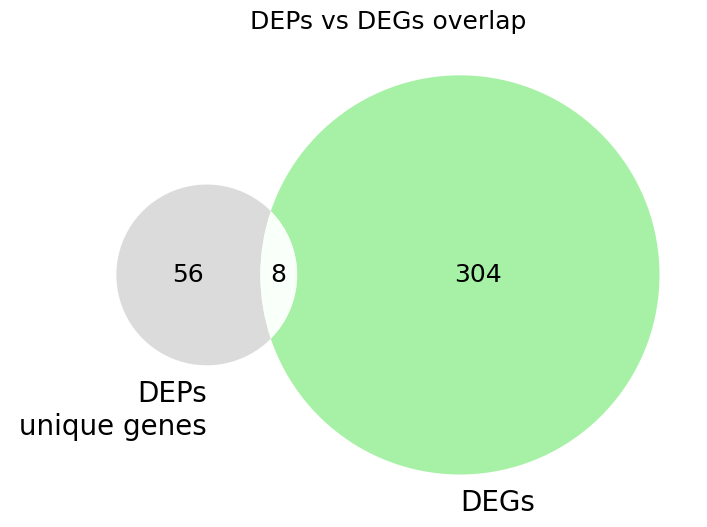

Common genes (8):
['ANXA2', 'CALB2', 'CRYM', 'CST3', 'GJA1', 'HBA1', 'MAOB', 'NECAB2']


In [28]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Load transcriptomics data
transcriptomics_DEGs = pd.read_excel(
    "GSE169755_DESeq2_DEGenes.xlsx",
    sheet_name="DESeq2DEGenes"
)

# Filter significant DEGs
sigs_DEGs = transcriptomics_DEGs[
    (transcriptomics_DEGs["padj"] <= 0.05) &
    (transcriptomics_DEGs["log2FoldChange"].abs() >= 1)
]

DEGs_list = sigs_DEGs["Unnamed: 0"].dropna().unique().tolist()

# Extract DEPs list (proteomics)
# NOTE: expects sigs dataframe from proteomics LIMMA/analysis step
gene_names_series = sigs_proteins["Gene names"].dropna()

DEPs_list = (
    gene_names_series
    .str.split(";")
    .str[0]
    .drop_duplicates()
    .tolist()
)

# Convert to sets
set_DEGs = set(DEGs_list)
set_DEPs = set(DEPs_list)

# Plot Venn diagram
plt.figure(figsize=(8, 8))

v = venn2(
    [set_DEPs, set_DEGs],
    set_labels=('DEPs\n unique genes', 'DEGs'),
    set_colors=("lightgrey", "lightgreen"),
    alpha=0.8
)

# Format labels
for text in v.set_labels:
    if text:
        text.set_fontsize(20)

for text in v.subset_labels:
    if text:
        text.set_fontsize(18)

plt.title("DEPs vs DEGs overlap", fontsize=18)

# Save figure
plt.savefig(
    "VENN_DEPs_vs_DEGs.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

# Common genes
common_genes = sorted(list(set_DEPs.intersection(set_DEGs)))

print(f"Common genes ({len(common_genes)}):")
print(common_genes)

### Common genes' Heatmap

In [35]:
import pandas as pd
from scipy.stats import spearmanr

# RNA-seq (DEGs) common genes
rna_common = sigs_DEGs[
    sigs_DEGs["Unnamed: 0"].isin(common_genes)
][["Unnamed: 0", "log2FoldChange"]].copy()

rna_common.columns = ["gene", "RNA_log2FC"]

# Proteomics (DEPs) common genes
prot = sigs_proteins.copy()

# Extract first gene name (safe split)
prot["gene"] = prot["Gene names"].astype(str).str.split(";").str[0]

prot_common = prot[
    prot["gene"].isin(common_genes)
][["gene", "log2FC"]].copy()

prot_common.columns = ["gene", "Prot_log2FC"]

# Merge RNA + Protein
merged = pd.merge(
    rna_common,
    prot_common,
    on="gene",
    how="inner"
)

# Drop missing values (important for correlation)
merged = merged.dropna()
print (merged)

rho, pval = spearmanr(merged['RNA_log2FC'], merged['Prot_log2FC'])

print("Spearman rho:", rho)
print("p-value:", pval)

     gene  RNA_log2FC  Prot_log2FC
0    CRYM    4.145568     0.576677
1    CST3    1.813056     0.852584
2    MAOB    2.045606     0.576551
3   CALB2    4.094249     0.889207
4   ANXA2    1.854132     1.088640
5    HBA1   -5.712767    -1.082213
6  NECAB2    2.560547     0.737592
7    GJA1    1.908616     0.588233
Spearman rho: 0.09523809523809526
p-value: 0.8225054302036114


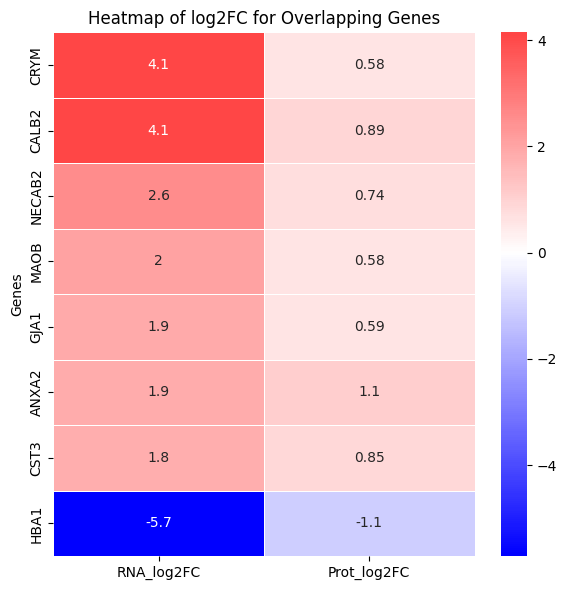

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare heatmap matrix
heatmap_data = merged.set_index("gene")[["RNA_log2FC", "Prot_log2FC"]].copy()

# Remove missing values (important for seaborn stability)
heatmap_data = heatmap_data.dropna()

# Sort by RNA log2FC (optional, but reproducible now explicit)
heatmap_data = heatmap_data.sort_values(by="RNA_log2FC", ascending=False)

# Plot heatmap
plt.figure(figsize=(6,6))

sns.heatmap(
    heatmap_data_sorted,
    annot=True,       # hücrede log2FC değerleri
    cmap='bwr',       # kırmızı-down, mavi-up
    center=0,
    linewidths=0.5
)

plt.title("Heatmap of log2FC for Overlapping Genes")
plt.ylabel("Genes")
plt.tight_layout()
plt.savefig("Heatmap_common_genes_sorted.png", dpi=300)
plt.show()